# 04 — Quantization v5 (10 activities, no per-user norm)

In [1]:
import numpy as np
import pickle
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.13.0


In [2]:
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models/v5')
DEPLOY_DIR = Path('../models')  # config.h and model_data.h go here for deployment
RESULTS_DIR = Path('../results/v5')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / 'preprocessing_info.pkl', 'rb') as f:
    info = pickle.load(f)

ACTIVITIES = info['activities']
NUM_CLASSES = info['num_classes']
SENSOR_MEAN = info['sensor_mean']
SENSOR_STD = info['sensor_std']
WINDOW_SIZE = info['window_size']
SAMPLING_RATE = info['sampling_rate']
NUM_FEATURES = info['num_features']

model = tf.keras.models.load_model(MODEL_DIR / 'best_model_v5.h5')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')
X_train_orig = np.load(DATA_DIR / 'X_train_original.npy')

orig_loss, orig_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Activities: {NUM_CLASSES} — {ACTIVITIES}')
print(f'Per-user norm: {info.get("per_user_normalization", "N/A")}')
print(f'Original model — Acc: {orig_acc:.4f}, Size: {Path(MODEL_DIR / "best_model_v5.h5").stat().st_size / 1024:.1f} KB')

2026-05-15 14:32:01.077967: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-15 14:32:01.078016: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-15 14:32:01.078028: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-15 14:32:01.078535: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-15 14:32:01.079003: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-15 14:32:01.667837: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Activities: 10 — ['ear_rubbing', 'forehead_rubbing', 'hair_pulling', 'hand_tapping', 'knuckles_cracking', 'nail_biting', 'nape_rubbing', 'sitting', 'smoking', 'standing']
Per-user norm: False
Original model — Acc: 0.7039, Size: 377.9 KB


In [3]:
def representative_dataset_gen():
    indices = np.random.choice(len(X_train_orig), size=min(200, len(X_train_orig)), replace=False)
    for i in indices:
        yield [X_train_orig[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
tflite_path = MODEL_DIR / 'activity_model_quantized_v5.tflite'
tflite_path.write_bytes(tflite_model)

quant_size = len(tflite_model) / 1024
orig_size = Path(MODEL_DIR / 'best_model_v5.h5').stat().st_size / 1024
print(f'Quantized: {quant_size:.1f} KB (from {orig_size:.1f} KB, {(1-quant_size/orig_size)*100:.1f}% reduction)')

INFO:tensorflow:Assets written to: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpkh01yj20/assets


INFO:tensorflow:Assets written to: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpkh01yj20/assets
/opt/homebrew/Caskroom/miniforge/base/envs/tinyml/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-15 14:32:10.020370: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-05-15 14:32:10.020663: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-05-15 14:32:10.021963: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /var/folders/52/bpf46hx95sl2yr7m61mcmnlw0000gn/T/tmpkh01yj20
2026-05-15 14:32:10.023448: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-05-15 14:32:10.023454: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /var/folders/52/bpf46

Quantized: 37.7 KB (from 377.9 KB, 90.0% reduction)


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [4]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale = input_details['quantization'][0]
input_zero_point = input_details['quantization'][1]
output_scale = output_details['quantization'][0]
output_zero_point = output_details['quantization'][1]

print(f'Input  — scale: {input_scale}, zp: {input_zero_point}')
print(f'Output — scale: {output_scale}, zp: {output_zero_point}')

Input  — scale: 0.1423172503709793, zp: -42
Output — scale: 0.00390625, zp: -128


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [5]:
# Evaluate quantized model
predictions = []
for i in range(len(X_test)):
    sample = X_test[i:i+1].astype(np.float32)
    q_input = (sample / input_scale + input_zero_point).astype(np.int8)
    interpreter.set_tensor(input_details['index'], q_input)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])[0]
    predictions.append((output.astype(np.float32) - output_zero_point) * output_scale)

quant_preds = np.array(predictions)
quant_pred_classes = quant_preds.argmax(axis=1)
quant_acc = np.mean(quant_pred_classes == y_test)

print(f'Original accuracy:  {orig_acc:.4f}')
print(f'Quantized accuracy: {quant_acc:.4f}')
print(f'Accuracy drop:      {(orig_acc - quant_acc)*100:.2f}%')

Original accuracy:  0.7039
Quantized accuracy: 0.6573
Accuracy drop:      4.66%


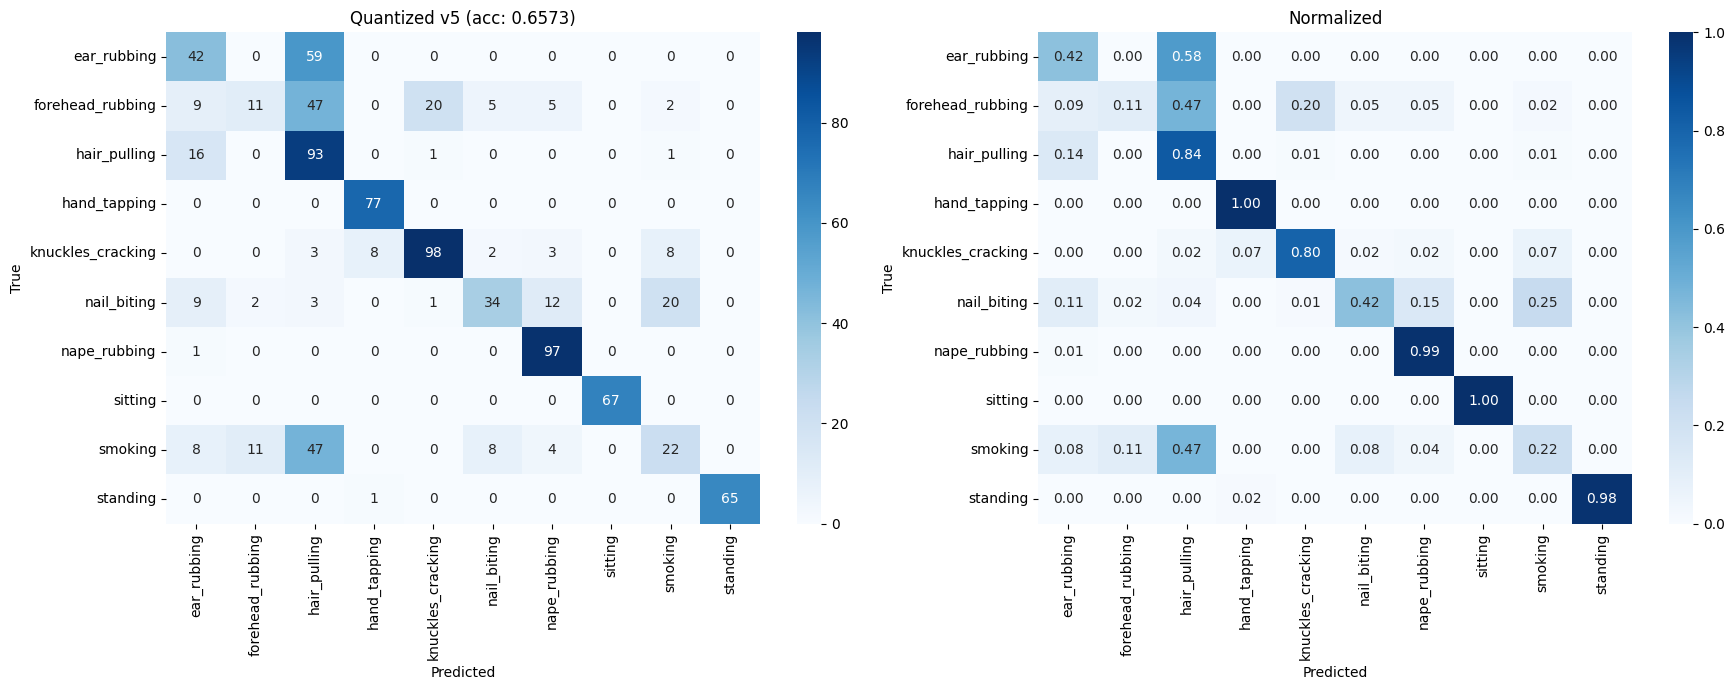

                   precision    recall  f1-score   support

      ear_rubbing     0.4941    0.4158    0.4516       101
 forehead_rubbing     0.4583    0.1111    0.1789        99
     hair_pulling     0.3690    0.8378    0.5124       111
     hand_tapping     0.8953    1.0000    0.9448        77
knuckles_cracking     0.8167    0.8033    0.8099       122
      nail_biting     0.6939    0.4198    0.5231        81
     nape_rubbing     0.8017    0.9898    0.8858        98
          sitting     1.0000    1.0000    1.0000        67
          smoking     0.4151    0.2200    0.2876       100
         standing     1.0000    0.9848    0.9924        66

         accuracy                         0.6573       922
        macro avg     0.6944    0.6782    0.6586       922
     weighted avg     0.6660    0.6573    0.6314       922



In [6]:
cm = confusion_matrix(y_test, quant_pred_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax1)
ax1.set_title(f'Quantized v5 (acc: {quant_acc:.4f})'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax2)
ax2.set_title('Normalized'); ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'quantized_v5_confusion_matrix.png', dpi=150)
plt.show()
print(classification_report(y_test, quant_pred_classes, target_names=ACTIVITIES, digits=4))

## Generate C Headers

In [7]:
# Save config.h to both v5 folder and deploy root
config_h = f"""#ifndef CONFIG_H
#define CONFIG_H

// Activity Recognition v5 — {NUM_CLASSES} activities
// No per-user normalization — global stats applied directly on raw sensor data

#define NUM_CLASSES {NUM_CLASSES}
#define NUM_RAW_FEATURES 6
#define NUM_FEATURES {NUM_FEATURES}  // 6 raw + 2 magnitude
#define WINDOW_SIZE {WINDOW_SIZE}
#define SAMPLING_RATE {SAMPLING_RATE}

// Feature order: Ax_w, Ay_w, Az_w, Gx_w, Gy_w, Gz_w, Acc_mag, Gyro_mag
// Acc_mag = sqrt(Ax^2 + Ay^2 + Az^2), Gyro_mag = sqrt(Gx^2 + Gy^2 + Gz^2)
// Normalize: (value - MEAN) / STD, then quantize to INT8
const float SENSOR_MEAN[{NUM_FEATURES}] = {{{', '.join(f'{v:.6f}f' for v in SENSOR_MEAN)}}};
const float SENSOR_STD[{NUM_FEATURES}] = {{{', '.join(f'{v:.6f}f' for v in SENSOR_STD)}}};

const float INPUT_SCALE = {input_scale}f;
const int8_t INPUT_ZERO_POINT = {input_zero_point};
const float OUTPUT_SCALE = {output_scale}f;
const int8_t OUTPUT_ZERO_POINT = {output_zero_point};

const char* ACTIVITY_LABELS[{NUM_CLASSES}] = {{
{chr(10).join(f'    "{act}",' for act in ACTIVITIES)}
}};

#endif
"""

Path(MODEL_DIR / 'config.h').write_text(config_h)
Path(DEPLOY_DIR / 'config.h').write_text(config_h)
print('config.h saved to v5/ and models/ root')
print(config_h)

config.h saved to v5/ and models/ root
#ifndef CONFIG_H
#define CONFIG_H

// Activity Recognition v5 — 10 activities
// No per-user normalization — global stats applied directly on raw sensor data

#define NUM_CLASSES 10
#define NUM_RAW_FEATURES 6
#define NUM_FEATURES 8  // 6 raw + 2 magnitude
#define WINDOW_SIZE 128
#define SAMPLING_RATE 50

// Feature order: Ax_w, Ay_w, Az_w, Gx_w, Gy_w, Gz_w, Acc_mag, Gyro_mag
// Acc_mag = sqrt(Ax^2 + Ay^2 + Az^2), Gyro_mag = sqrt(Gx^2 + Gy^2 + Gz^2)
// Normalize: (value - MEAN) / STD, then quantize to INT8
const float SENSOR_MEAN[8] = {0.196717f, 0.093949f, -0.451440f, -0.930565f, 1.677287f, 0.128417f, 0.996089f, 29.968271f};
const float SENSOR_STD[8] = {0.595617f, 0.485070f, 0.393003f, 42.673264f, 20.773724f, 19.017673f, 0.083101f, 41.498489f};

const float INPUT_SCALE = 0.1423172503709793f;
const int8_t INPUT_ZERO_POINT = -42;
const float OUTPUT_SCALE = 0.00390625f;
const int8_t OUTPUT_ZERO_POINT = -128;

const char* ACTIVITY_LABELS[10] = {
    "

In [8]:
model_bytes = tflite_model
hex_lines = []
for i in range(0, len(model_bytes), 12):
    chunk = model_bytes[i:i+12]
    hex_lines.append('  ' + ', '.join(f'0x{b:02x}' for b in chunk) + ',')

model_data_h = f"""#ifndef MODEL_DATA_H
#define MODEL_DATA_H

// IDCNN v5 — {NUM_CLASSES} activities, {NUM_FEATURES} features
// Size: {len(model_bytes):,} bytes

alignas(8) const unsigned char activity_model_data[] = {{
{chr(10).join(hex_lines)}
}};

const unsigned int activity_model_data_len = {len(model_bytes)};

#endif
"""

Path(MODEL_DIR / 'model_data.h').write_text(model_data_h)
Path(DEPLOY_DIR / 'model_data.h').write_text(model_data_h)
print(f'model_data.h saved to v5/ and models/ root ({len(model_data_h):,} bytes, model: {len(model_bytes):,} bytes)')

model_data.h saved to v5/ and models/ root (238,211 bytes, model: 38,592 bytes)


In [9]:
print('=' * 50)
print('QUANTIZATION v5 SUMMARY')
print('=' * 50)
print(f'Activities:         {NUM_CLASSES}')
print(f'Per-user norm:      No (deployable)')
print(f'Original accuracy:  {orig_acc:.4f}')
print(f'Quantized accuracy: {quant_acc:.4f}')
print(f'Accuracy drop:      {(orig_acc - quant_acc)*100:.2f}%')
print(f'Quantized size:     {quant_size:.1f} KB')
print(f'Model binary:       {len(model_bytes):,} bytes')
print(f'\nFiles saved to models/v5/:')
print(f'  best_model_v5.h5, activity_model_quantized_v5.tflite')
print(f'  config.h, model_data.h')
print(f'\nDeployment files also saved to models/ root:')
print(f'  config.h, model_data.h')
print(f'\nCopy models/config.h and models/model_data.h to IMU_Classifier/')

QUANTIZATION v5 SUMMARY
Activities:         10
Per-user norm:      No (deployable)
Original accuracy:  0.7039
Quantized accuracy: 0.6573
Accuracy drop:      4.66%
Quantized size:     37.7 KB
Model binary:       38,592 bytes

Files saved to models/v5/:
  best_model_v5.h5, activity_model_quantized_v5.tflite
  config.h, model_data.h

Deployment files also saved to models/ root:
  config.h, model_data.h

Copy models/config.h and models/model_data.h to IMU_Classifier/
